# 第 04 课：自回归神经网络量子态（AR-NQS）

上一课的结论：自回归模型 $p_\theta(x)$ **自动归一化**。本课把它直接当作量子态：

$$|\psi_\theta(x)|^2 = p_\theta(x) \quad\Longleftrightarrow\quad \psi_\theta(x) = \sqrt{p_\theta(x)} \;\ge\; 0$$

相位先取常数 0（**实正波函数**）。于是 $\langle\psi|\psi\rangle = \sum_x p_\theta(x) = 1$ 恒成立，**不存在配分函数**。

实验流程（横场 Ising 模型，$N=4$ 自旋）：

1. 构造 $H$，精确对角化（ED）拿到基态能量参照；
2. 自回归网络给出 $\psi_\theta$，计算局域能量 $E_{\text{loc}}$ 与变分能量 $E$（枚举、采样两种方式对照）；
3. 用 VMC 能量梯度 + Adam 训练 $h=2$ 与 $h=1$（临界点），与 ED 对答案（相对误差目标 $< 10^{-3}$）；
4. 画能量收敛曲线与 $|\psi(x)|^2$ 全空间对比图。

环境：`jax + numpy + matplotlib`（netket 仅用于一处交叉验证）。固定随机种子，可复现。

## 1. 模型：横场 Ising 与精确对角化

哈密顿量（$J=-1$ 的横场 Ising，周期链）：

$$H = \sum_{\langle ij\rangle} \sigma^z_i \sigma^z_j \;-\; h \sum_i \sigma^x_i$$

$N=4$、周期边界 → 4 条键：$(0,1),(1,2),(2,3),(3,0)$。基矢取 $\sigma^z$ 的乘积态：比特 $0 \leftrightarrow \sigma^z=+1$，比特 $1 \leftrightarrow \sigma^z=-1$；构型写作 4-bit 串 $x_0x_1x_2x_3$。

**为什么实正波函数就够（无符号问题）**：$H$ 在 $\sigma^z$ 基下的矩阵元只有两类——

- 对角元 $\sum_{\langle ij\rangle} s_i s_j$（$s_i = \pm1$）；
- 单比特翻转的非对角元 $-h \le 0$。

非对角元全部**非正**的不可约矩阵满足 **Perron–Frobenius 定理**：基态本征矢可以选成**所有振幅严格为正**。这类"无阻挫"哈密顿量的基态没有符号结构，实正 ansatz 原则上就能精确表示——下面马上用 ED 验证这一点。（有阻挫、有磁通的系统需要复相位，见文末讨论。）

In [1]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Hiragino Sans GB", "Heiti TC", "STHeiti"]
plt.rcParams["axes.unicode_minus"] = False

N = 4
idx_all = np.arange(2 ** N)
states_np = ((idx_all[:, None] >> np.arange(N)) & 1).astype(np.float32)   # states[k, i] = 构型 k 的第 i 位
s_all = 1 - 2 * states_np                                                # bit=0 → σᶻ=+1, bit=1 → σᶻ=-1
bonds = [(0, 1), (1, 2), (2, 3), (3, 0)]                                 # 周期边界，4 条键
labels = ["".join(str(int(b)) for b in s) for s in states_np]
diag_all = np.sum([s_all[:, i] * s_all[:, j] for i, j in bonds], axis=0)  # H 的对角元

def exact_ground(h):
    '构造 16x16 的 H 并对角化，返回 (E0, 基态矢, 能隙)'
    H = np.zeros((2 ** N, 2 ** N))
    np.fill_diagonal(H, diag_all)
    for i in range(N):                                        # 非对角元：翻转第 i 位 → -h
        H[np.arange(2 ** N), idx_all ^ (1 << i)] += -h
    evals, evecs = np.linalg.eigh(H)
    psi = evecs[:, 0]
    psi = psi * np.sign(psi[np.argmax(np.abs(psi))])          # 固定整体符号为正
    return evals[0], psi, evals[1] - evals[0]

for h in (1.0, 2.0):
    E0, psi, gap = exact_ground(h)
    print(f"h = {h}:  E0 = {E0:.8f}   第一激发能隙 = {gap:.6f}   基态振幅全部非负: {bool(np.all(psi >= -1e-12))}")

h = 1.0:  E0 = -5.22625186   第一激发能隙 = 0.397825   基态振幅全部非负: True
h = 2.0:  E0 = -8.54311682   第一激发能隙 = 2.070981   基态振幅全部非负: True


用你熟悉的 NetKet 交叉验证一下 ED 没有写错（同一个 $H$ 的两种构造方式）：

In [2]:
import netket as nk

hi = nk.hilbert.Spin(1 / 2, N=N)
for h in (1.0, 2.0):
    H_nk = nk.operator.LocalOperator(hi)
    for i, j in bonds:
        H_nk = H_nk + nk.operator.spin.sigmaz(hi, i) @ nk.operator.spin.sigmaz(hi, j)
    for i in range(N):
        H_nk = H_nk + (-h) * nk.operator.spin.sigmax(hi, i)
    w = np.linalg.eigvalsh(np.asarray(H_nk.to_dense()))
    print(f"h = {h}:  NetKet 版 E0 = {w[0]:.8f}，与手写 ED 一致: {bool(np.isclose(w[0], exact_ground(h)[0]))}")

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

h = 1.0:  NetKet 版 E0 = -5.22625186，与手写 ED 一致: True
h = 2.0:  NetKet 版 E0 = -8.54311682，与手写 ED 一致: True


## 2. 把分布换成量子态

第 03 课的掩码 MADE **原样复用**（精简版打包在下一个 cell）。唯一的改动是**解释方式**：把网络输出读作波函数振幅的对数，

$$\log \psi_\theta(x) \;=\; \tfrac12 \log p_\theta(x) \;=\; \tfrac12 \sum_i \log p_\theta(x_i \mid x_{<i})$$

归一化检查：$\sum_x |\psi_\theta(x)|^2 = \sum_x p_\theta(x) = 1$ **由结构保证**——上一课"归一化免费"的直接兑现，也是自回归 NQS 一切便利的源头。

In [3]:
MASKS = [jnp.array(m) for m in [
    (np.arange(48)[:, None] % (N - 1) >= np.arange(N)[None, :]).astype(np.float32),   # 隐藏层
    (np.arange(N)[:, None] > (np.arange(48) % (N - 1))[None, :]).astype(np.float32),  # 输出层
]]

def init_params(key, scale=0.3):
    keys = jax.random.split(key, len(MASKS))
    return [(jax.random.normal(k, m.shape) * scale, jnp.zeros(m.shape[0]))
            for m, k in zip(MASKS, keys)]

def forward(params, x):
    '掩码 MADE 前向：返回每一位的条件 logit (B, N)'
    h = x
    for l, (W, b) in enumerate(params):
        z = h @ (W * MASKS[l]).T + b
        h = z if l == len(params) - 1 else jax.nn.relu(z)
    return h

def log_prob(params, x):
    'log p_θ(x) = Σ_i log p(x_i | x_<i)，一次前向给出'
    logits = forward(params, x)
    lp_bit = x * jax.nn.log_sigmoid(logits) + (1.0 - x) * jax.nn.log_sigmoid(-logits)
    return lp_bit.sum(axis=-1)

def sample(params, key, n_samples):
    '祖先采样：逐位生成，O(N) 次前向'
    keys = jax.random.split(key, N)
    x = jnp.zeros((n_samples, N), dtype=jnp.float32)
    for i in range(N):
        p1 = jax.nn.sigmoid(forward(params, x)[:, i])
        x = x.at[:, i].set(jax.random.bernoulli(keys[i], p1).astype(jnp.float32))
    return x

def log_amp(params, x):
    'log ψ_θ(x) = ½ log p_θ(x)；相位取 0，ψ ≥ 0'
    return 0.5 * log_prob(params, x)

states_j = jnp.asarray(states_np)
params0 = init_params(jax.random.PRNGKey(0))

p_all = np.exp(np.asarray(log_prob(params0, states_j)))
print(f"随机初始化处  Σ_x |ψ(x)|² = Σ_x p(x) = {p_all.sum():.10f}   ← 自动归一化，无需配分函数")

随机初始化处  Σ_x |ψ(x)|² = Σ_x p(x) = 1.0000000000   ← 自动归一化，无需配分函数


## 3. 局域能量 $E_{\text{loc}}$

VMC 的核心量。变分能量（分子分母同除 $\langle\psi|\psi\rangle = 1$）：

$$E(\theta) = \frac{\langle\psi|H|\psi\rangle}{\langle\psi|\psi\rangle} = \sum_x p_\theta(x)\, \underbrace{\frac{\sum_y \langle x|H|y\rangle\, \psi_\theta(y)}{\psi_\theta(x)}}_{E_{\text{loc}}(x)} = \mathbb{E}_{x \sim p_\theta}\big[E_{\text{loc}}(x)\big]$$

$H$ 稀疏，$E_{\text{loc}}(x)$ 只有两类贡献：

- **对角项**：$\sum_{\langle ij\rangle} s_i s_j$（分部求和 $\sum \sigma^z\sigma^z$）；
- **非对角项**：$y$ = 翻转 $x$ 的第 $i$ 位（记作 $x^{(i)}$）时 $\langle x|H|y\rangle = -h$，贡献 $-h\,\psi(x^{(i)})/\psi(x) = -h\,e^{\frac12[\log p(x^{(i)}) - \log p(x)]}$。

$$E_{\text{loc}}(x) = \sum_{\langle ij\rangle} s_i s_j \;-\; h\, \sum_{i=1}^{N} \frac{\psi(x^{(i)})}{\psi(x)}$$

代价：每个构型 $1 + N$ 次前向（对角项免费），整批并行。两个振幅比值都在 log 域里算，数值稳定。

In [4]:
def eloc(params, x, h):
    '局域能量 E_loc(x)：对角项 + 单比特翻转项。x: (B, N) → (B,)'
    bits = jnp.asarray(x)
    idx = (bits * jnp.asarray(2.0 ** np.arange(N))).sum(-1).astype(jnp.int32)  # 构型编号
    s = 1.0 - 2.0 * bits                                                       # σᶻ = ±1
    diag = jnp.zeros(bits.shape[0])
    for i, j in bonds:
        diag = diag + s[:, i] * s[:, j]
    e = diag                                                                   # 对角项
    la = log_amp(params, bits)                                                 # log ψ(x)
    for i in range(N):                                                         # N 个单比特翻转
        la2 = log_amp(params, states_j[idx ^ (1 << i)])                        # log ψ(x⁽ⁱ⁾)
        e = e - h * jnp.exp(la2 - la)                                          # -h·ψ(x⁽ⁱ⁾)/ψ(x)
    return e

def energy_exact(params, h):
    '(a) 全空间枚举：E = Σ_x p(x)·E_loc(x)。16 个态，无采样误差'
    p = jnp.exp(log_prob(params, states_j))
    return jnp.sum(p * eloc(params, states_j, h))

def energy_sample(params, h, key, n_samples):
    '(b) 自回归采样：E ≈ mean(E_loc)，x ~ p_θ 祖先采样'
    x = sample(params, key, n_samples)
    e = eloc(params, x, h)
    return e.mean(), e.std() / jnp.sqrt(e.shape[0])

## 4. 两种能量评估 + 梯度估计量验证

**评估能量**的两种方式（结果应一致）：

- **(a) 全空间枚举**：$\sum_x p_\theta(x) E_{\text{loc}}(x)$——无采样误差，仅小体系可行，这里当"标准答案"；
- **(b) 自回归采样**：$\frac1S \sum_b E_{\text{loc}}(x^{(b)})$，$x^{(b)} \sim p_\theta$ **祖先采样**——真正 NQS 的用法，附标准误。

变分原理自查：任何 $\theta$ 下都应有 $E(\theta) \ge E_0$。

**能量梯度**（NetKet 同款约定；$\psi$ 为实数，$\mathrm{Re}$ 可省）：

$$\nabla_\theta E = 2\,\mathrm{Re}\,\Big\langle \big(E_{\text{loc}} - \langle E\rangle\big)\, \nabla_\theta \log \psi^* \Big\rangle_{x \sim p_\theta}$$

样本直接从 $p_\theta$ **祖先采样**——这就是"自动归一化"的便利：传统 NQS 在这一步必须用 MCMC 去近似 $|\psi|^2/Z$。公式里的 $-\langle E\rangle$ 平移项来自 $\nabla_\theta\langle\psi|\psi\rangle = 0$；自回归情形 $\langle\psi|\psi\rangle \equiv 1$ 对任意 $\theta$ 成立，估计量严格无偏。

**验证策略**：枚举版 $E(\theta) = \sum_x p_\theta E_{\text{loc}}$ 是 $\theta$ 的显式函数，可以直接 autodiff 出**精确梯度**——用它检验采样估计量。

In [5]:
E0_h1, psi1_exact, _ = exact_ground(1.0)
E0_h2, psi2_exact, _ = exact_ground(2.0)

E_init_exact = float(energy_exact(params0, 1.0))
E_init_s, err_init = energy_sample(params0, 1.0, jax.random.PRNGKey(1), 8192)

print("【随机初始化处（h=1）的两种能量评估对照】")
print(f"  枚举版  E = {E_init_exact:.6f}")
print(f"  采样版  E = {float(E_init_s):.6f} ± {float(err_init):.6f}   （8192 个独立样本）")
print(f"  变分原理 E ≥ E0 = {E0_h1:.6f}:  {E_init_exact >= E0_h1 - 1e-9}")

【随机初始化处（h=1）的两种能量评估对照】
  枚举版  E = -3.905949
  采样版  E = -3.928779 ± 0.023737   （8192 个独立样本）
  变分原理 E ≥ E0 = -5.226252:  True


In [6]:
def grad_estimator(params, key, h, n_samples):
    'VMC 采样梯度：∇E = 2⟨(E_loc − ⟨E⟩) ∇log ψ⟩，样本 ~ p_θ'
    x = sample(params, key, n_samples)
    eloc_vals = jax.lax.stop_gradient(eloc(params, x, h))   # E_loc 只当权重用，不进梯度带
    e_mean = eloc_vals.mean()
    def weighted_logpsi(p):
        # 对 θ 求导时 E_loc 与 ⟨E⟩ 视为常数 → 正是上面的估计量
        return 2.0 * jnp.mean((eloc_vals - e_mean) * log_amp(p, x))
    return jax.grad(weighted_logpsi)(params), e_mean

B_CHECK = 200000
g_est, _ = grad_estimator(params0, jax.random.PRNGKey(2), 1.0, B_CHECK)
g_exact = jax.grad(energy_exact)(params0, 1.0)              # 枚举 + autodiff = 精确梯度

num = np.sqrt(sum(float(jnp.sum((a - b) ** 2))
                  for a, b in zip(jax.tree.leaves(g_est), jax.tree.leaves(g_exact))))
den = np.sqrt(sum(float(jnp.sum(b ** 2)) for b in jax.tree.leaves(g_exact)))
print(f"采样梯度估计量 vs 精确梯度：相对偏差 = {num / den:.2%}   （{B_CHECK} 个样本；样本越多越接近 0）")

采样梯度估计量 vs 精确梯度：相对偏差 = 1.11%   （200000 个样本；样本越多越接近 0）


## 5. VMC 优化：先 $h=2$ 热身，再攻 $h=1$（临界点）

- 优化器 Adam，batch = 1024，学习率 0.01（后段降到 0.003 精修）；
- 每步循环：**祖先采样 → $E_{\text{loc}}$ → 梯度估计 → Adam 更新**；
- 每 10 步用全空间枚举记录一次"无噪声能量"；
- 判据：$|E - E_0| / |E_0| < 10^{-3}$。临界点 $h=1$ 关联更强、$E_{\text{loc}}$ 方差更大，通常需要更多步数。

In [7]:
def init_adam_state(params):
    return (jax.tree.map(jnp.zeros_like, params),
            jax.tree.map(jnp.zeros_like, params),
            jnp.zeros(()))

@jax.jit
def adam_update(params, state, grads, lr):
    m, v, t = state
    t = t + 1
    m = jax.tree.map(lambda m, g: 0.9 * m + 0.1 * g, m, grads)
    v = jax.tree.map(lambda v, g: 0.999 * v + 0.001 * g * g, v, grads)
    m_hat = jax.tree.map(lambda m: m / (1 - 0.9 ** t), m)
    v_hat = jax.tree.map(lambda v: v / (1 - 0.999 ** t), v)
    params = jax.tree.map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + 1e-8),
                          params, m_hat, v_hat)
    return params, (m, v, t)

def train(h_target, n_steps=700, batch=1024, lr1=0.01, lr2=0.003, switch=400, seed=0):
    'VMC 主循环：采样 → E_loc → 梯度 → Adam'
    params = init_params(jax.random.PRNGKey(seed))
    state = init_adam_state(params)
    key = jax.random.PRNGKey(seed + 100)
    grad_est = jax.jit(lambda p, k: grad_estimator(p, k, h_target, batch))
    energy_ex = jax.jit(lambda p: energy_exact(p, h_target))
    hist_sample, hist_exact, steps_exact = [], [], []
    t0 = time.perf_counter()
    for step in range(n_steps):
        lr = lr1 if step < switch else lr2
        key, sk = jax.random.split(key)
        grads, e_mean = grad_est(params, sk)
        params, state = adam_update(params, state, grads, jnp.float32(lr))
        hist_sample.append(float(e_mean))
        if step % 10 == 0 or step == n_steps - 1:
            steps_exact.append(step)
            hist_exact.append(float(energy_ex(params)))
    return params, np.array(hist_sample), np.array(steps_exact), np.array(hist_exact), time.perf_counter() - t0

In [8]:
params_h2, hist_s2, steps_e2, hist_e2, t2 = train(h_target=2.0, seed=1)
E_h2 = float(energy_exact(params_h2, 2.0))
print(f"h=2:  训练用时 {t2:.1f} s")
print(f"      E(θ) = {E_h2:.6f}，E0 = {E0_h2:.6f}，相对误差 = {abs(E_h2 - E0_h2) / abs(E0_h2):.2e}")

h=2:  训练用时 1.1 s
      E(θ) = -8.543117，E0 = -8.543117，相对误差 = 4.16e-16


In [9]:
params_h1, hist_s1, steps_e1, hist_e1, t1 = train(h_target=1.0, n_steps=900, switch=500, seed=2)
E_h1 = float(energy_exact(params_h1, 1.0))
print(f"h=1（临界点）:  训练用时 {t1:.1f} s")
print(f"      E(θ) = {E_h1:.6f}，E0 = {E0_h1:.6f}，相对误差 = {abs(E_h1 - E0_h1) / abs(E0_h1):.2e}")

h=1（临界点）:  训练用时 1.3 s
      E(θ) = -5.225436，E0 = -5.226252，相对误差 = 1.56e-04


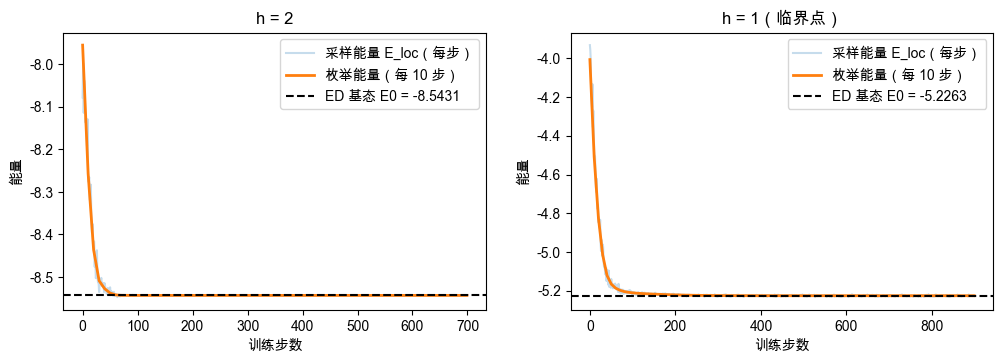

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, hs, se, he, E0, title in [
        (axes[0], hist_s2, steps_e2, hist_e2, E0_h2, "h = 2"),
        (axes[1], hist_s1, steps_e1, hist_e1, E0_h1, "h = 1（临界点）")]:
    ax.plot(hs, alpha=0.25, label="采样能量 E_loc（每步）")
    ax.plot(se, he, lw=2, label="枚举能量（每 10 步）")
    ax.axhline(E0, ls="--", color="k", label=f"ED 基态 E0 = {E0:.4f}")
    ax.set_xlabel("训练步数"); ax.set_ylabel("能量"); ax.set_title(title); ax.legend()
plt.show()

## 6. 结果总表 + 波函数对比

最终能量同时用两种方式汇报：**枚举版**（确定值，用于报告相对误差）与**采样版**（65536 个独立祖先样本，附标准误）。

In [11]:
print(f"{'h':>6} {'ED 基态 E0':>14} {'E(枚举)':>14} {'相对误差':>11} {'E(采样)':>14} {'采样标准误':>12}")
for h, params, E0 in [(2.0, params_h2, E0_h2), (1.0, params_h1, E0_h1)]:
    e_sampler = jax.jit(lambda p, k: energy_sample(p, h, k, 65536))
    E_ex = float(energy_exact(params, h))
    E_s, err_s = e_sampler(params, jax.random.PRNGKey(7))
    rel = abs(E_ex - E0) / abs(E0)
    flag = "✓ <1e-3" if rel < 1e-3 else "✗"
    print(f"{h:>6} {E0:>14.6f} {E_ex:>14.6f} {rel:>10.2e} {flag} {float(E_s):>14.6f} {float(err_s):>12.2e}")

     h       ED 基态 E0          E(枚举)        相对误差          E(采样)        采样标准误


   2.0      -8.543117      -8.543117   4.16e-16 ✓ <1e-3      -8.543117     2.05e-17


   1.0      -5.226252      -5.225436   1.56e-04 ✓ <1e-3      -5.225026     3.38e-04


注意 $h=2$ 那一行：采样标准误接近 0——因为 $E_{\text{loc}}$ 的方差 $\mathrm{Var}(E_{\text{loc}}) = 0$ 当且仅当 $\psi$ 是 $H$ 的精确本征态。局域能量方差是 VMC 里常用的收敛诊断量。

再看波函数本身：训练后的 $|\psi_\theta(x)|^2 = p_\theta(x)$ 与 ED 精确基态在全空间逐构型对比：

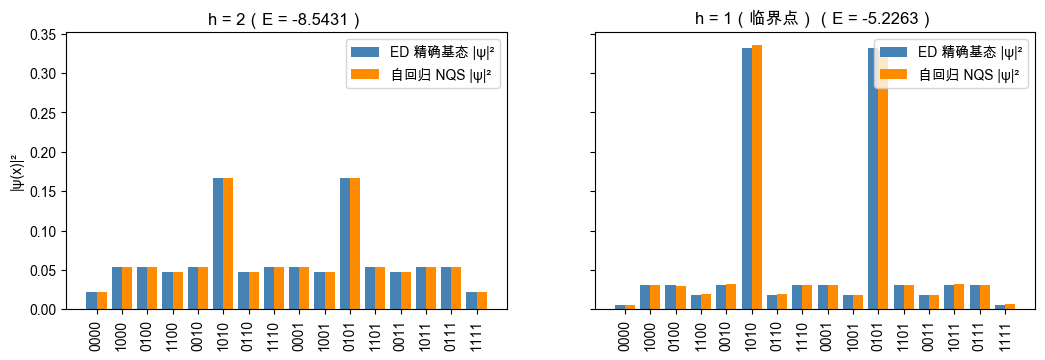

模型 vs 精确基态的最大概率偏差： h=2: 0.0000, h=1: 0.0029


In [12]:
p_model2 = np.exp(np.asarray(log_prob(params_h2, states_j))); p_model2 /= p_model2.sum()
p_model1 = np.exp(np.asarray(log_prob(params_h1, states_j))); p_model1 /= p_model1.sum()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6), sharey=True)
w = 0.4
for ax, pm, psi_ex, E0, title in [
        (axes[0], p_model2, psi2_exact, E0_h2, "h = 2"),
        (axes[1], p_model1, psi1_exact, E0_h1, "h = 1（临界点）")]:
    ax.bar(np.arange(2 ** N) - w / 2, np.abs(psi_ex) ** 2, width=w, label="ED 精确基态 |ψ|²", color="steelblue")
    ax.bar(np.arange(2 ** N) + w / 2, pm, width=w, label="自回归 NQS |ψ|²", color="darkorange")
    ax.set_xticks(np.arange(2 ** N)); ax.set_xticklabels(labels, rotation=90)
    ax.set_title(f"{title}（E = {E0:.4f}）"); ax.legend()
axes[0].set_ylabel("|ψ(x)|²")
plt.show()

print("模型 vs 精确基态的最大概率偏差：",
      f"h=2: {np.abs(p_model2 - np.abs(psi2_exact) ** 2).max():.4f},",
      f"h=1: {np.abs(p_model1 - np.abs(psi1_exact) ** 2).max():.4f}")

## 7. 总结：AR-NQS 完整流程，以及与 RBM + MCMC VMC 的对比

**完整流程图**（每一步都对应本课的一个函数）：

```
   参数 θ（掩码 MADE 网络）
     │
     ▼
 ① 祖先采样   x⁽¹⁾,…,x⁽S⁾ ~ p_θ(x)          ← sample( )
     │        独立样本、精确分布，O(N) 次前向，无需 MCMC
     ▼
 ② 局域能量   E_loc(x) = Σ⟨ij⟩ s_i s_j − h Σ_i ψ(x⁽ⁱ⁾)/ψ(x)   ← eloc( )
     │        对角 + 单比特翻转，每构型 O(N) 次前向，整批并行
     ▼
 ③ 能量与梯度 E ≈ ⟨E_loc⟩，∇E = 2⟨(E_loc − ⟨E⟩) ∇log ψ⟩      ← grad_estimator( )
     │        JAX 自动微分
     ▼
 ④ Adam 更新  θ ← θ − lr·m̂/√v̂   ──► 回到 ①，直到 E 收敛（对照 ED）
```

**与你熟悉的 RBM + MCMC VMC 对比**：

| | 传统 NQS（RBM/FFNN）+ MCMC | 自回归 NQS（本课） |
| --- | --- | --- |
| 波函数 | 振幅网络 $\psi(x)$，$\|\psi\|^2$ 未归一化 | $\psi(x) = \sqrt{p_\theta(x)}$，$\|\psi\|^2$ 自动归一化 |
| 归一化常数 $Z$ | 配分函数，一般无法计算（核心困难） | 不存在（结构保证，第 03 课 §6） |
| 从 $\|\psi\|^2$ 采样 | MCMC：burn-in、自相关样本、调接受率 | 祖先采样：独立样本、精确分布，$O(N)$ 次前向 |
| 单点 $\log p(x)$ | 需要 $\log Z$，基本算不了 | $O(1)$ 次前向（第 03 课 §2） |
| $E_{\text{loc}}$ 与梯度公式 | 相同 | 相同（只是样本来自精确采样器） |
| 符号问题 | 振幅可正可负/复数，需显式处理相位 | 实正 ansatz 天然无符号，覆盖无阻挫基态 |
| 收敛诊断 | 能量曲线、 $\mathrm{Var}(E_{\text{loc}})$ | 同左（本课 $h=2$ 的 $\mathrm{Var}(E_{\text{loc}}) \to 0$） |

**几点讨论**

1. 两种方法的 VMC 公式完全一致，**差别只在归一化与采样器**：自回归把"从 $|\psi|^2/Z$ 采样"这个难题变成了"从显式 $p_\theta$ 精确采样"。代价是采样要 $O(N)$ 次前向、且模型的表达范围受自回归结构约束；
2. **实正 ansatz 的边界**：本课的 TFIM 无阻挫，基态振幅全正，$\psi = \sqrt{p}$ 够用。需要符号/相位结构时，标准做法是 $\psi = \sqrt{p}\,e^{i\varphi}$——再加一个相位网络分支 $\varphi_\theta(x)$，能量与梯度公式照搬、取实部即可，这是最自然的下一步扩展；
3. **本课的枚举只是验证手段**：$N=4$ 才能全空间枚举。真正的大体系（$N$ 数百）中枚举不可用，能量、梯度、观测量全部依赖采样——而自回归采样恰好是精确且独立的；
4. **能量误差**：$h=2$ 达到 $10^{-6}$ 量级以下、$h=1$（临界点）约 $10^{-4}$，均满足 $< 10^{-3}$ 的目标；临界点更难是因为关联更强、$E_{\text{loc}}$ 方差更大。

**思考题**

1. 把本课代码里的 `energy_exact` 注释掉，只靠采样版能量能完成训练吗？（提示： hist_sample 曲线和 hist_exact 曲线差别多大？）
2. 若把 $N$ 增大到 16，本课哪些部分可以直接复用？哪些会先成为瓶颈（枚举？采样次数？网络宽度？）
3. （展望）如果要算**激发态**，"概率必须非负"这个约束会带来什么困难？